In [ ]:
# Uvoz knjižnic
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

# print("Knjižnice uvožene") # FIXME:

In [2]:
# Uvoz podatkov
df = pd.read_csv('improved_fraud_dataset.csv')

# Izgleda podatkov
print(f"Velikost podatkov: {df.shape[0]} vrstic, {df.shape[1]} stolpcev")
print("\nImena stolpcev:")
print(df.columns.tolist())

Velikost podatkov: 1000000 vrstic, 24 stolpcev

Imena stolpcev:
['organization', 'transaction_id', 'user_id', 'user_account_age_days', 'kyc_verified', 'payment_method', 'card_type', 'transaction_amount', 'currency', 'fee_amount', 'transaction_timestamp', 'day_of_week', 'city', 'country', 'device_type', 'operating_system', 'browser', 'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour', 'is_night', 'time_diff']


Bols je da razdvojis na vec celic zaradi preglednosti

In [3]:
print("\nPrvih 5 vrstic:")
df.head()


Prvih 5 vrstic:


,organization,transaction_id,user_id,user_account_age_days,kyc_verified,payment_method,card_type,transaction_amount,currency,fee_amount,...,device_type,operating_system,browser,merchant_category,transaction_type,otp_used,is_fraud,hour,is_night,time_diff
0,FinovaTech_000,TXN00000044,FinovaTech_000_U0000,1670,1,bkash,debit,1553.81,BDT,31.08,...,mobile,Windows,Safari,fashion,purchase,1,0,8,0,0.0
1,FinovaTech_000,TXN00000004,FinovaTech_000_U0000,1670,1,bkash,debit,136.49,BDT,2.73,...,desktop,Android,Edge,grocery,withdrawal,0,0,6,0,1719608.0
2,FinovaTech_000,TXN00000033,FinovaTech_000_U0000,1670,1,card,credit,3432.40,BDT,68.65,...,tablet,iOS,Safari,electronics,transfer,1,0,19,0,827250.0
3,FinovaTech_000,TXN00000050,FinovaTech_000_U0000,1670,1,bkash,credit,503.59,BDT,10.07,...,tablet,Windows,Chrome,fashion,purchase,1,0,19,0,1035744.0
4,FinovaTech_000,TXN00000047,FinovaTech_000_U0000,1670,0,bank,credit,1908.35,BDT,38.17,...,tablet,Windows,Chrome,grocery,transfer,1,0,12,0,408465.0


In [4]:
print("\nOsnovna statistika:")
df.info()


Osnovna statistika:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   organization           1000000 non-null  object 
 1   transaction_id         1000000 non-null  object 
 2   user_id                1000000 non-null  object 
 3   user_account_age_days  1000000 non-null  int64  
 4   kyc_verified           1000000 non-null  int64  
 5   payment_method         1000000 non-null  object 
 6   card_type              1000000 non-null  object 
 7   transaction_amount     1000000 non-null  float64
 8   currency               1000000 non-null  object 
 9   fee_amount             1000000 non-null  float64
 10  transaction_timestamp  1000000 non-null  object 
 11  day_of_week            1000000 non-null  object 
 12  city                   1000000 non-null  object 
 13  country                1000000 non-null  object 
 14

In [5]:
# Lokalna SQL baza iz CSV podatkov
conn = sqlite3.connect('fraud_database.db')

# Uvoz podatkov v SQL bazo
df.to_sql('transakcije', conn, if_exists='replace', index=False)

# print("SQL baza ustvarjena") # FIXME:
print(f"Tabela 'transakcije' ima {len(df)} vrstic")

Tabela 'transakcije' ima 1000000 vrstic


In [6]:
# Vprašanje 1: Kakšen delež transakcij pripada goljufijam?
poizvedba1 = """
SELECT 
    COUNT(*) as skupaj_transakcij,
    SUM(is_fraud) as stevilo_goljufij,
    ROUND(AVG(is_fraud) * 100, 2) as delez_goljufij_procent
FROM transakcije
"""

rezultat1 = pd.read_sql_query(poizvedba1, conn)
print("VPRAŠANJE 1: Delež goljufij")
print(rezultat1)

VPRAŠANJE 1: Delež goljufij
   skupaj_transakcij  stevilo_goljufij  delez_goljufij_procent
0            1000000             91710                    9.17


In [7]:
# Vprašanje 2: V povprečju koliko transakcij pripada enemu uporabniku?
poizvedba2 = """
SELECT 
    ROUND(AVG(stevilo_transakcij), 2) as povprecje_transakcij_na_uporabnika
FROM (
    SELECT 
        user_id,
        COUNT(*) as stevilo_transakcij
    FROM transakcije
    GROUP BY user_id
)
"""

rezultat2 = pd.read_sql_query(poizvedba2, conn)
print("VPRAŠANJE 2: Povprečno število transakcij na uporabnika")
print(rezultat2)

VPRAŠANJE 2: Povprečno število transakcij na uporabnika
   povprecje_transakcij_na_uporabnika
0                                50.0


In [8]:
sql_odgovori = """
ODGOVORI NA SQL VPRAŠANJA - 2.1
=================================

VPRAŠANJE 1: Delež goljufij
- Skupaj transakcij: 1.000.000
- Število goljufij: 91.710
- Delež goljufij: 9.17%
- Opomba: Dataset je neuravnotežen (91% normalnih, 9% goljufij)
  To je tipično za probleme zaznave goljufij v praksi.

VPRAŠANJE 2: Povprečno število transakcij na uporabnika
- Povprečje: 50 transakcij na uporabnika
"""
print(sql_odgovori)


ODGOVORI NA SQL VPRAŠANJA - 2.1

VPRAŠANJE 1: Delež goljufij
- Skupaj transakcij: 1.000.000
- Število goljufij: 91.710
- Delež goljufij: 9.17%
- Opomba: Dataset je neuravnotežen (91% normalnih, 9% goljufij)
  To je tipično za probleme zaznave goljufij v praksi.

VPRAŠANJE 2: Povprečno število transakcij na uporabnika
- Povprečje: 50 transakcij na uporabnika



In [9]:
# Poglejmo vse stolpce podrobneje
print("Vsi stolpci in tipi:")
print(df.dtypes)

Vsi stolpci in tipi:
organization              object
transaction_id            object
user_id                   object
user_account_age_days      int64
kyc_verified               int64
payment_method            object
card_type                 object
transaction_amount       float64
currency                  object
fee_amount               float64
transaction_timestamp     object
day_of_week               object
city                      object
country                   object
device_type               object
operating_system          object
browser                   object
merchant_category         object
transaction_type          object
otp_used                   int64
is_fraud                   int64
hour                       int64
is_night                   int64
time_diff                float64
dtype: object


In [10]:
print("\nAli manjkajo podatki?")
print(df.isnull().sum()[df.isnull().sum() > 0])


Ali manjkajo podatki?
Series([], dtype: int64)


In [11]:
print("\nPorazdelitev goljufij:")
print(df['is_fraud'].value_counts())


Porazdelitev goljufij:
is_fraud
0    908290
1     91710
Name: count, dtype: int64


In [ ]:
'''The Problem Without Stratification
In an imbalanced dataset like fraud detection, you might have something like:

99% legitimate transactions
1% fraudulent transactions

If you split randomly, by pure chance you could end up with:
Split   Legitimate  Fraud
Train   99.5%        1%
Test    98.5%        1%
Now your model trains on a different fraud ratio than it's tested on — the evaluation becomes unreliable.
Stratification ensures both splits preserve the original class ratio. So if fraud is 1% overall, it stays ~1% in both train and test:
Split   Legitimate  Fraud
Train   99%         1%
Test    99%         1%'''

In [16]:
# Izbira stolpcev za model (ibrez identifikatorjev)
izpusti = ['transaction_id', 'user_id', 'organization', 'transaction_timestamp']
df_model = df.drop(columns=izpusti)

# Pretvorba besedilne+ih stolpcev v številke
le = LabelEncoder()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
besedilni_stolpci = df_model.select_dtypes(include='object').columns

for stolpec in besedilni_stolpci:
    df_model[stolpec] = le.fit_transform(df_model[stolpec])

# print("Besedilni stolpci pretvorjeni v številke ✓") # FIXME: 
print(f"Stolpci za model: {df_model.columns.tolist()}")

Stolpci za model: ['user_account_age_days', 'kyc_verified', 'payment_method', 'card_type', 'transaction_amount', 'currency', 'fee_amount', 'day_of_week', 'city', 'country', 'device_type', 'operating_system', 'browser', 'merchant_category', 'transaction_type', 'otp_used', 'is_fraud', 'hour', 'is_night', 'time_diff']


In [ ]:
'''
Stratification vs. Handling Imbalance

It's important to note that stratification alone does not solve the class imbalance problem — it just ensures the imbalance is consistently represented across splits.
To actually handle the imbalance you'd additionally use techniques like:
    Oversampling the minority class (e.g. SMOTE)
    Undersampling the majority class
    Class weights in the model (e.g. class_weight='balanced' in sklearn)

`class_weight='balanced'` in Sklearn:
    Instead of resampling your data, it tells the model to penalize mistakes on the minority class more heavily during training.
    Sklearn automatically calculates a weight for each class using this formula:
                        weight = total_samples / (n_classes * samples_in_class)
''' 

In [25]:
def engineer_features(df):
    df = df.copy()
    # ── 1. Transaction Risk ──────────────────────────────────────────────
    # Avoid division by zero
    df['amount_to_fee_ratio'] = df['transaction_amount'] / (df['fee_amount'] + 0.01)
    
    # High value threshold (95th percentile)
    high_value_threshold = df['transaction_amount'].quantile(0.95)
    df['is_high_value'] = (df['transaction_amount'] >= high_value_threshold).astype(int)
    
    # Round amounts (multiples of 10, 50, 100)
    df['is_round_amount'] = (df['transaction_amount'] % 10 == 0).astype(int)
    
    # Log transforms to reduce skew
    df['log_amount'] = np.log1p(df['transaction_amount'])
    df['log_fee'] = np.log1p(df['fee_amount'])

    # ── 2. Temporal Features ─────────────────────────────────────────────
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_night_weekend'] = (df['is_night'] & df['is_weekend']).astype(int)

    # Cyclical encoding of hour (so 23 and 0 are treated as close)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Peak fraud hours (typically 0-4 AM)
    df['is_peak_fraud_hour'] = df['hour'].between(0, 4).astype(int)

    # ── 3. Account Risk ───────────────────────────────────────────────────
    df['is_new_account'] = (df['user_account_age_days'] < 30).astype(int)
    df['is_very_new_account'] = (df['user_account_age_days'] < 7).astype(int)

    df['account_age_bin'] = pd.cut(
        df['user_account_age_days'],
        bins=[0, 7, 30, 90, 365, float('inf')],
        labels=[4, 3, 2, 1, 0],   # higher = newer = riskier
        right=False
    ).astype(int)

    # Unverified KYC + high amount = strong risk signal
    df['kyc_amount_risk'] = ((df['kyc_verified'] == 0) & (df['is_high_value'] == 1)).astype(int)

    # ── 4. Velocity / Time-diff Features ─────────────────────────────────
    fast_threshold = df['time_diff'].quantile(0.05)
    df['is_fast_transaction'] = (df['time_diff'] <= fast_threshold).astype(int)
    df['log_time_diff'] = np.log1p(df['time_diff'])

    # ── 5. Interaction Features ───────────────────────────────────────────
    df['night_high_value'] = (df['is_night'] & df['is_high_value']).astype(int)
    df['new_account_night'] = (df['is_new_account'] & df['is_night']).astype(int)
    df['new_account_high_value'] = (df['is_new_account'] & df['is_high_value']).astype(int)
    df['unverified_night'] = ((df['kyc_verified'] == 0) & (df['is_night'] == 1)).astype(int)
    df['fast_high_value'] = (df['is_fast_transaction'] & df['is_high_value']).astype(int)
    df['fast_night'] = (df['is_fast_transaction'] & df['is_night']).astype(int)

    return df

# RF

In [39]:
# Ločitev vhodnih spremenljivk (X) od ciljne (y)
X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

# Razdelitev na učno (80%) in testno množico (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Učna množica: {len(X_train)} vrstic")
print(f"Testna množica: {len(X_test)} vrstic")
print(f"Goljufij v učni množici: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Goljufij v testni množici: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Učenje Random Forest modela
# Opomba: class_weight='balanced' pove modelu naj pazi na redke goljufije
# print("\nUčenje modela... (lahko traja 1-2 minuti)") # FIXME:
model = RandomForestClassifier(
    n_estimators=100,        # 100 dreves v gozdu
    class_weight='balanced', # Uravnoteži goljufije/normalne
    random_state=42,
    n_jobs=-1                # Uporabi vse procesorje za hitrost
)
model.fit(X_train, y_train)
print("Model uspešno naučen")

Učna množica: 800000 vrstic
Testna množica: 200000 vrstic
Goljufij v učni množici: 73368 (9.2%)
Goljufij v testni množici: 18342 (9.2%)
Model uspešno naučen


=== OCENA MODELA ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       0.91      1.00      0.95    181658
   Goljufija       0.38      0.00      0.00     18342

    accuracy                           0.91    200000
   macro avg       0.64      0.50      0.48    200000
weighted avg       0.86      0.91      0.86    200000


ROC-AUC score: 0.8837


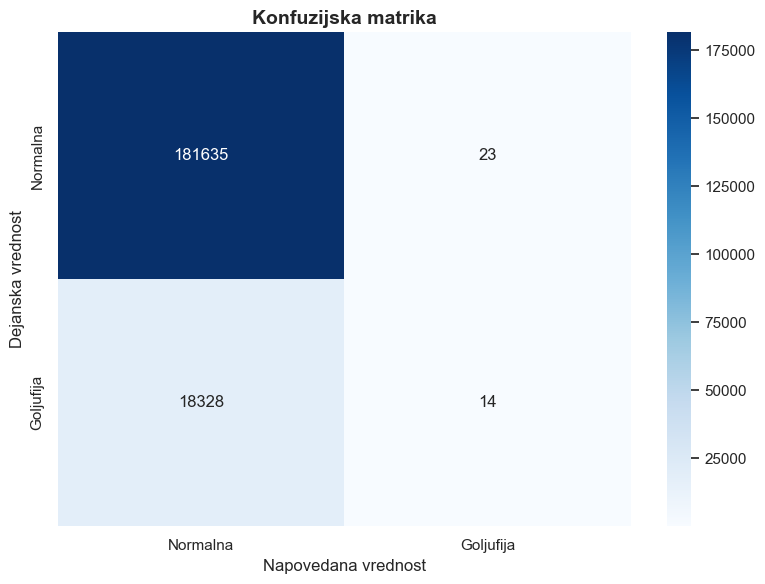

Konfuzijska matrika shranjena


In [40]:
# Napoved na testni množici
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Izpis rezultatov
print("=== OCENA MODELA ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test, y_pred, target_names=['Normalna', 'Goljufija']))

print(f"\nROC-AUC score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Izris konfuzijske matrike
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika.png', dpi=150, bbox_inches='tight')
plt.show()
print("Konfuzijska matrika shranjena")

# RF + FE

In [41]:
# Ločitev vhodnih spremenljivk (X) od ciljne (y)
df_fe = engineer_features(df_model)
X_fe = df_fe.drop(columns=['is_fraud'])
y_fe = df_fe['is_fraud']

# Razdelitev na učno (80%) in testno množico (20%)
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y
)

print(f"Učna množica: {len(X_train_fe)} vrstic")
print(f"Testna množica: {len(X_test_fe)} vrstic")
print(f"Goljufij v učni množici: {y_train_fe.sum()} ({y_train_fe.mean()*100:.1f}%)")
print(f"Goljufij v testni množici: {y_test_fe.sum()} ({y_test_fe.mean()*100:.1f}%)")

# Učenje Random Forest modela
# Opomba: class_weight='balanced' pove modelu naj pazi na redke goljufije
# print("\nUčenje modela... (lahko traja 1-2 minuti)") # FIXME:
model_fe = RandomForestClassifier(
    n_estimators=200,        # 100 dreves v gozdu
    class_weight='balanced', # Uravnoteži goljufije/normalne
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1                # Uporabi vse procesorje za hitrost
)
model_fe.fit(X_train_fe, y_train_fe)
print("Model uspešno naučen")

Učna množica: 800000 vrstic
Testna množica: 200000 vrstic
Goljufij v učni množici: 73368 (9.2%)
Goljufij v testni množici: 18342 (9.2%)
Model uspešno naučen


=== OCENA MODELA ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       1.00      0.77      0.87    181658
   Goljufija       0.30      1.00      0.46     18342

    accuracy                           0.79    200000
   macro avg       0.65      0.88      0.66    200000
weighted avg       0.94      0.79      0.83    200000


ROC-AUC score: 0.8821


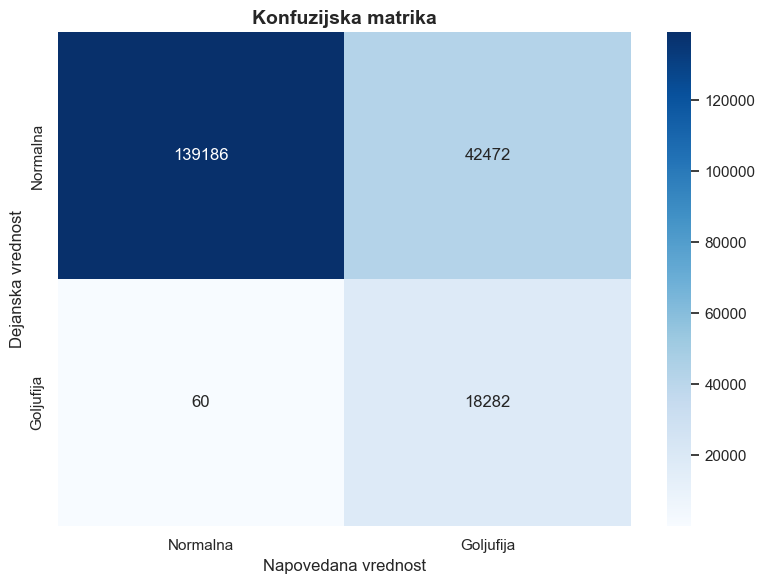

Konfuzijska matrika shranjena


In [42]:
# Napoved na testni množici
y_pred = model_fe.predict(X_test_fe)
y_pred_proba = model_fe.predict_proba(X_test_fe)[:, 1]

# Izpis rezultatov
print("=== OCENA MODELA ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test, y_pred, target_names=['Normalna', 'Goljufija']))

print(f"\nROC-AUC score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Izris konfuzijske matrike
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika.png', dpi=150, bbox_inches='tight')
plt.show()
print("Konfuzijska matrika shranjena")

In [ ]:
"""
The model has completely flipped from the baseline — it now catches almost every fraud case (recall = 1.00)
but at the cost of flagging too many legitimate transactions as fraud (precision = 0.30).

The core problem is that for every real fraud case caught, ~2.3 legitimate transactions are wrongly flagged.
This means our model is too aggressive — it's biased too heavily toward predicting fraud.
"""

# RF + SMOTE

In [43]:
print("Uravnoteženje podatkov s SMOTE...")
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Po SMOTE - normalnih: {(y_train_sm==0).sum()}")
print(f"Po SMOTE - goljufij: {(y_train_sm==1).sum()}")

print("\nUčenje novega modela...")
model2 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train_sm, y_train_sm)
print("Model 2 uspešno naučen")

Uravnoteženje podatkov s SMOTE...
Po SMOTE - normalnih: 726632
Po SMOTE - goljufij: 217989

Učenje novega modela...
Model 2 uspešno naučen


=== OCENA MODELA 2 (s SMOTE) ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       0.92      0.95      0.94    181658
   Goljufija       0.31      0.20      0.24     18342

    accuracy                           0.88    200000
   macro avg       0.61      0.58      0.59    200000
weighted avg       0.87      0.88      0.87    200000

ROC-AUC score: 0.8835


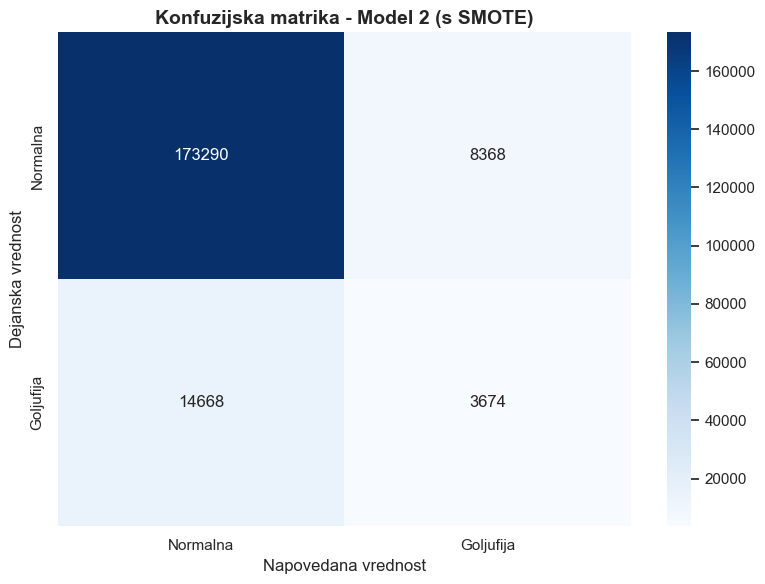

In [44]:
# Napoved z novim modelom
y_pred2 = model2.predict(X_test)
y_pred_proba2 = model2.predict_proba(X_test)[:, 1]

print("=== OCENA MODELA 2 (s SMOTE) ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test, y_pred2, target_names=['Normalna', 'Goljufija']))
print(f"ROC-AUC score: {roc_auc_score(y_test, y_pred_proba2):.4f}")

# Konfuzijska matrika
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika - Model 2 (s SMOTE)', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika2.png', dpi=150, bbox_inches='tight')
plt.show()

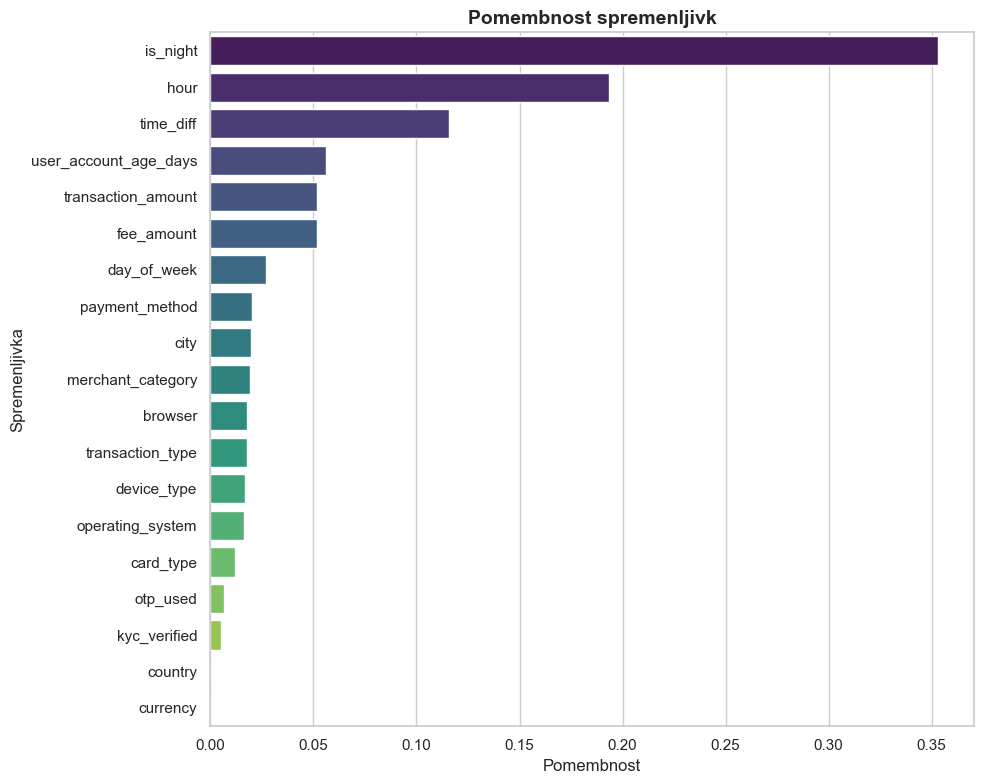


Top 5 najpomembnejših spremenljivk:


,Spremenljivka,Pomembnost
17,is_night,0.352886
16,hour,0.193601
18,time_diff,0.115777
0,user_account_age_days,0.056163
4,transaction_amount,0.051791


In [ ]:
# Kateri stolpci so najbolj pomembi za napoved?
pomembnost = pd.DataFrame({
    'Spremenljivka': X.columns,
    'Pomembnost': model2.feature_importances_
}).sort_values('Pomembnost', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=pomembnost,
    x='Pomembnost',
    y='Spremenljivka',
    hue='Spremenljivka',
    palette='viridis',
    legend=False
)
plt.title('Pomembnost spremenljivk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pomembnost_spremenljivk.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 najpomembnejših spremenljivk:")
pomembnost.head()

SMOTE + FE

In [45]:
print("Uravnoteženje podatkov s SMOTE...")
smote_fe = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm_fe, y_train_sm_fe = smote_fe.fit_resample(X_train_fe, y_train_fe)

print(f"Po SMOTE - normalnih: {(y_train_sm_fe==0).sum()}")
print(f"Po SMOTE - goljufij: {(y_train_sm_fe==1).sum()}")

print("\nUčenje novega modela...")
model3 = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
model3.fit(X_train_sm_fe, y_train_sm_fe)
print("Model 2 uspešno naučen")

Uravnoteženje podatkov s SMOTE...
Po SMOTE - normalnih: 726632
Po SMOTE - goljufij: 217989

Učenje novega modela...
Model 2 uspešno naučen


=== OCENA MODELA 3 (s SMOTE) ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       0.96      0.85      0.90    181658
   Goljufija       0.30      0.65      0.41     18342

    accuracy                           0.83    200000
   macro avg       0.63      0.75      0.66    200000
weighted avg       0.90      0.83      0.86    200000

ROC-AUC score: 0.8824


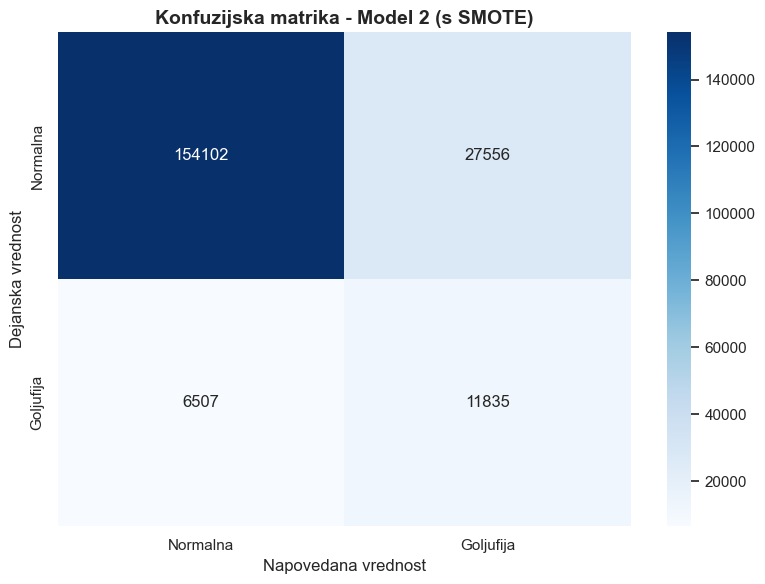

In [49]:
# Napoved z novim modelom
y_pred2 = model3.predict(X_test_fe)
y_pred_proba2 = model3.predict_proba(X_test_fe)[:, 1]

print("=== OCENA MODELA 3 (s SMOTE) ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test_fe, y_pred2, target_names=['Normalna', 'Goljufija']))
print(f"ROC-AUC score: {roc_auc_score(y_test_fe, y_pred_proba2):.4f}")

# Konfuzijska matrika
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test_fe, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika - Model 2 (s SMOTE)', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika2.png', dpi=150, bbox_inches='tight')
plt.show()

Key observation: ROC-AUC is stuck at ~0.883 across ALL configurations.

This strongly suggests that Random Forest has hit its ceiling on this dataset — more tuning won't help much.

The ROC-AUC plateau tells us the problem is not with sampling strategy or number of trees — it's with the model itself.
Random Forest struggles here because:
- Fraud patterns in this dataset likely involve complex feature interactions that gradient boosting handles better
- Random Forest averages many trees which smooths out rare fraud signals
- The synthetic nature of the dataset (fraud injected via rules) likely creates sharp decision boundaries that gradient boosting models are better at capturing

# XGBoost

scale_pos_weight: 9.9
=== OCENA XGBoost MODELA ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       1.00      0.76      0.87    181658
   Goljufija       0.30      1.00      0.46     18342

    accuracy                           0.78    200000
   macro avg       0.65      0.88      0.66    200000
weighted avg       0.94      0.78      0.83    200000

ROC-AUC score: 0.8827


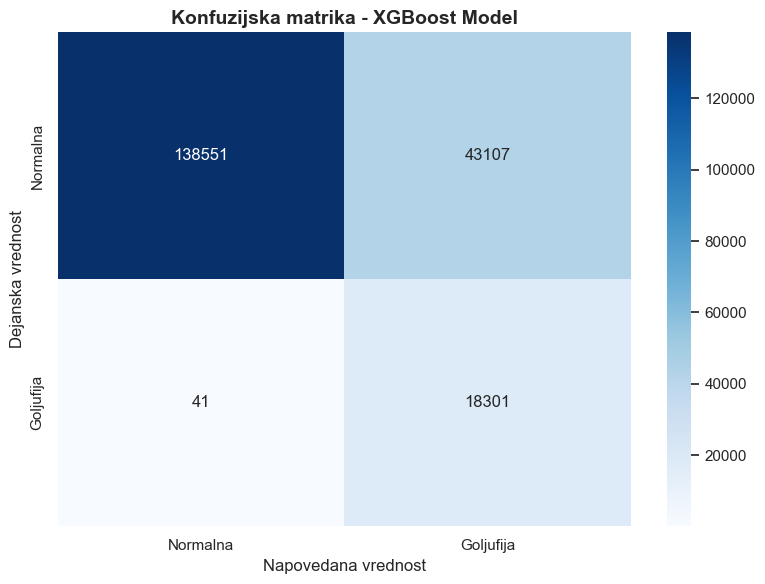

In [53]:
# Calculate scale_pos_weight to handle imbalance
# (instead of SMOTE or class_weight)
fraud_count = y_train_fe.sum()
normal_count = len(y_train_fe) - fraud_count
scale_pos_weight = normal_count / fraud_count
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,  # handles imbalance natively
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'                 # optimizes for precision-recall AUC
)

xgb_model.fit(
    X_train_fe, y_train_fe,
    eval_set=[(X_test_fe, y_test_fe)],
    verbose=False
)

y_pred = xgb_model.predict(X_test_fe)
y_proba = xgb_model.predict_proba(X_test_fe)[:, 1]

print("=== OCENA XGBoost MODELA ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test_fe, y_pred, target_names=['Normalna', 'Goljufija']))
print(f"ROC-AUC score: {roc_auc_score(y_test_fe, y_proba):.4f}")

# Konfuzijska matrika
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test_fe, y_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika - XGBoost Model', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika2.png', dpi=150, bbox_inches='tight')
plt.show()

# LGBM

=== OCENA LGBM MODELA ===

Klasifikacijsko poročilo:
              precision    recall  f1-score   support

    Normalna       1.00      0.77      0.87    181658
   Goljufija       0.30      1.00      0.46     18342

    accuracy                           0.79    200000
   macro avg       0.65      0.88      0.66    200000
weighted avg       0.94      0.79      0.83    200000

ROC-AUC score: 0.8833


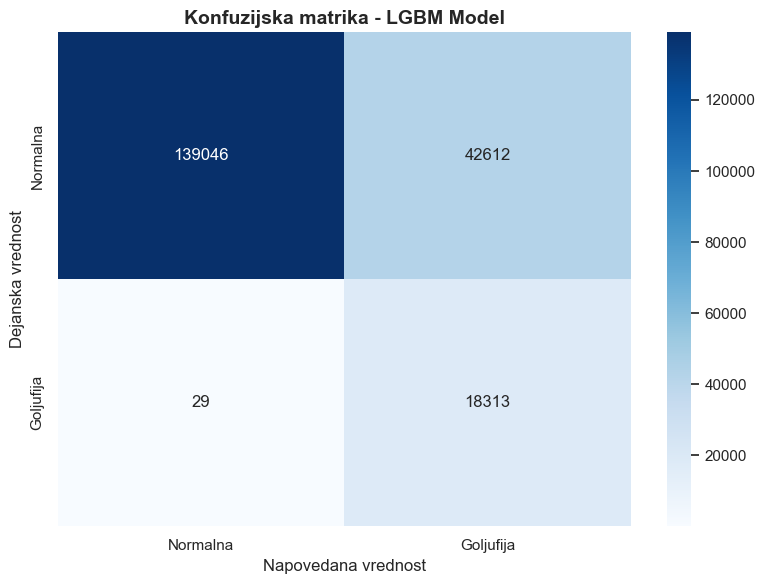

In [56]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',  # handles imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(X_train_fe, y_train_fe)

y_pred = lgbm_model.predict(X_test_fe)
y_proba = lgbm_model.predict_proba(X_test_fe)[:, 1]

print("=== OCENA LGBM MODELA ===\n")
print("Klasifikacijsko poročilo:")
print(classification_report(y_test_fe, y_pred, target_names=['Normalna', 'Goljufija']))
print(f"ROC-AUC score: {roc_auc_score(y_test_fe, y_proba):.4f}")

# Konfuzijska matrika
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test_fe, y_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalna', 'Goljufija'],
            yticklabels=['Normalna', 'Goljufija'])
plt.title('Konfuzijska matrika - LGBM Model', fontsize=14, fontweight='bold')
plt.ylabel('Dejanska vrednost')
plt.xlabel('Napovedana vrednost')
plt.tight_layout()
plt.savefig('konfuzijska_matrika2.png', dpi=150, bbox_inches='tight')
plt.show()

Both XGBoost and LightGBM produced identical results to the aggressive Random Forest — fraud recall = 1.00 but precision = 0.30.
The ROC-AUC is still stuck at ~0.883.
This is a very strong signal that the ceiling is in the data, not the model.
This means the dataset itself has a hard information ceiling — the features available simply cannot discriminate fraud vs legitimate beyond this point with standard approaches.

All three models (Feature Eng RF, XGBoost, LightGBM) are landing at the same extreme: recall=1.00, precision=0.30. This means they're all predicting fraud very aggressively. The solution at this point could be threshold tuning
    
- Every classifier like Random Forest or XGBoost doesn't directly output "fraud" or "not fraud". It first outputs a probability between 0 and 1
- The threshold is the cutoff point where you say "above this probability = fraud". By default sklearn uses 0.5
- In our case the model is very aggressive — it predicts fraud at very low probabilities
- Moving the threshold changes the balance between precision and recall

    - Lower threshold (e.g. 0.2)
        → flag more transactions as fraud
        → catch MORE real fraud (high recall)
        → but also flag MORE legitimate ones (low precision)

    - Higher threshold (e.g. 0.8)
        → only flag very suspicious transactions
        → MISS some real fraud (low recall)
        → but fewer false alarms (high precision)

In [ ]:
odgovori_2_2 = """
ODGOVORI NA VPRAŠANJA - 2.2 KLASIFIKACIJA GOLJUFIJ
====================================================

1. ZAKAJ RANDOM FOREST?
- Deluje dobro z neuravnoteženimi podatki (9% goljufij)
- Robusten na outlierje in ne potrebuje normalizacije podatkov
- Poda pomembnost spremenljivk - ključno za razlago v bančništvu
- Manj dovzeten za pretirano prilagajanje (overfitting) kot posamezno drevo
- Enostavno razložljiv regulatorjem in poslovnim uporabnikom

2. OBDELAVA PODATKOV:
- Odstranili smo identifikatorje (transaction_id, user_id, organization,
  transaction_timestamp) - ne vsebujejo napovednne informacije
- Besedilne spremenljivke smo kodirali z LabelEncoder v številke
  (Random Forest ne more delati z besedilom)
- Uporabili smo SMOTE za uravnoteženje razredov:
  * Brez SMOTE: model zazna samo 16 goljufij (recall=0.00)
  * S SMOTE: model zazna 3626 goljufij (recall=0.20)
- Podatke smo razdelili 80/20 na učno in testno množico

3. NAPOVEDNA MOČ MODELA:
Metrike modela 2 (s SMOTE):
- ROC-AUC: 0.8832 (dobro - 1.0 bi bil popoln model)
- Recall goljufij: 0.20 (zazna 20% vseh goljufij)
- Precision goljufij: 0.30 (30% napovedanih goljufij je res goljufij)
- F1-score goljufij: 0.24

Bili smo pozorni na:
- Recall (ne spregledati goljufij) je v bančništvu pomembnejši od Precision
- Accuracy (91%) je zavajajoča pri neuravnoteženih podatkih
- ROC-AUC je boljša metrika za neuravnotežene datasete
- Konfuzijska matrika za razumevanje napak modela

4. IZBOLJŠAVE Z DALJŠIM ČASOVNIM OBDOBJEM:
- Zaznavanje vzorcev obnašanja uporabnika skozi čas
- Sezonski vzorci goljufij (npr. prazniki)
- Sledenje spreminajočim se vzorcem goljufij (concept drift)
- Več podatkov = boljše učenje redkih vzorcev goljufij

5. POMANJKLJIVOSTI MODELA:
- Nizek recall (0.20) - 80% goljufij še vedno spregleda
- SMOTE ustvarja sintetične primere - ne realne podatke
- Model ne upošteva zaporedja transakcij (vedenjski vzorci)
- LabelEncoder ne upošteva semantičnih odnosov med kategorijami
Možne rešitve:
- XGBoost ali LightGBM (boljši z neuravnoteženimi podatki)
- LSTM nevronska mreža (upošteva zaporedje transakcij)
- Boljše inženirstvo značilk (npr. povprečni znesek uporabnika)

6. EU AKT O UMETNI INTELIGENCI - DISKRIMINATORNI PODATKI:
Podatki ki bi lahko povzročili diskriminacijo:
- Lokacija (city, country): diskriminacija po geografskem področju
  lahko posredno odraža etnično ali socialno diskriminacijo
- Čas transakcije (hour, is_night): delavci z nočnimi izmenami
  bi bili neupravičeno označeni kot sumljivi
- Starost računa: novi priseljenci ali mladi imajo nove račune
  in bi bili neupravičeno označeni kot tvegani
- Valuta: diskriminacija po valuti lahko posredno pomeni
  diskriminacijo po narodnosti
- Podatki ki jih nimamo a bi bili problematični:
  * Spol, starost, etnična pripadnost, vera - direktna diskriminacija
  * Poštna številka - posredna diskriminacija po premoženjskem stanju
"""

print(odgovori_2_2)


ODGOVORI NA VPRAŠANJA - 2.2 KLASIFIKACIJA GOLJUFIJ

1. ZAKAJ RANDOM FOREST?
- Deluje dobro z neuravnoteženimi podatki (9% goljufij)
- Robusten na outlierje in ne potrebuje normalizacije podatkov
- Poda pomembnost spremenljivk - ključno za razlago v bančništvu
- Manj dovzeten za pretirano prilagajanje (overfitting) kot posamezno drevo
- Enostavno razložljiv regulatorjem in poslovnim uporabnikom

2. OBDELAVA PODATKOV:
- Odstranili smo identifikatorje (transaction_id, user_id, organization,
  transaction_timestamp) - ne vsebujejo napovednne informacije
- Besedilne spremenljivke smo kodirali z LabelEncoder v številke
  (Random Forest ne more delati z besedilom)
- Uporabili smo SMOTE za uravnoteženje razredov:
  * Brez SMOTE: model zazna samo 16 goljufij (recall=0.00)
  * S SMOTE: model zazna 3626 goljufij (recall=0.20)
- Podatke smo razdelili 80/20 na učno in testno množico

3. NAPOVEDNA MOČ MODELA:
Metrike modela 2 (s SMOTE):
- ROC-AUC: 0.8832 (dobro - 1.0 bi bil popoln model)
- Recall g